# Exercise 09: traveling salesman problem
<b> Write a code to solve the TSP with a **Genetic** algorithm (GA). Apply your code to the optimization of a path among 

-  <b>34 cities randomly placed **on** a circumference  <b>
- <b>34 cities randomly placed **inside** a square<b>

**Show your results via:**

- <b>a picture of $L^{(2)}$ (or $L^{(1)}$) of the best path and of $\langle L^{(2)}\rangle$ (or $\langle L^{(1)}\rangle$), averaged on the best half of the population, as a function of the iterations/generations of your algorithm <b>
-  <b>a picture of the best path in cartesian coordinates  <b>

#### Defining the structure

To solvw the travelling salesman problem I built a genetic algorithm based on hierarchical structures:
-  <b>struct gene </b>: struct that represents a single city, its elements are an index that is used to identify it, and its position
- <b>class chromosome</b>: class that represents a single path betweencities, its main element is an std vector <gene> which has _ngenes+1 element. When the class is initialized the size of the vector is set to ncities+1, and positions are assigned to each gene randomly, but always keeping the first and last element equal to each other and equal to zero, representing the fact that the salesman returns to their starting place. Each chromosome also has a member _cost, which contains the value of L1, the total distance travelled inthe path. This class also contains all the functions that perform operations on a single chromosome, like permutations, mutations and crossover, which I will talk about in more detail later. 
- <b>class GeneticOptimizer</b>: this class is where the actual optimization of the problem is performed. It contains an element _population, which is an std vector of chromomosomes, and when initialized it creates N chromosomes by making a random number of permutations on an initial vector, and repeating N times.This class contains function that allow to sort the population from lower to higher distance travelled, select the parents, and perform the actual optimization to find the best path.

In the following plot I show a visual representation of 3 random chromosomes in the population, to show how the different paths are represented in the population

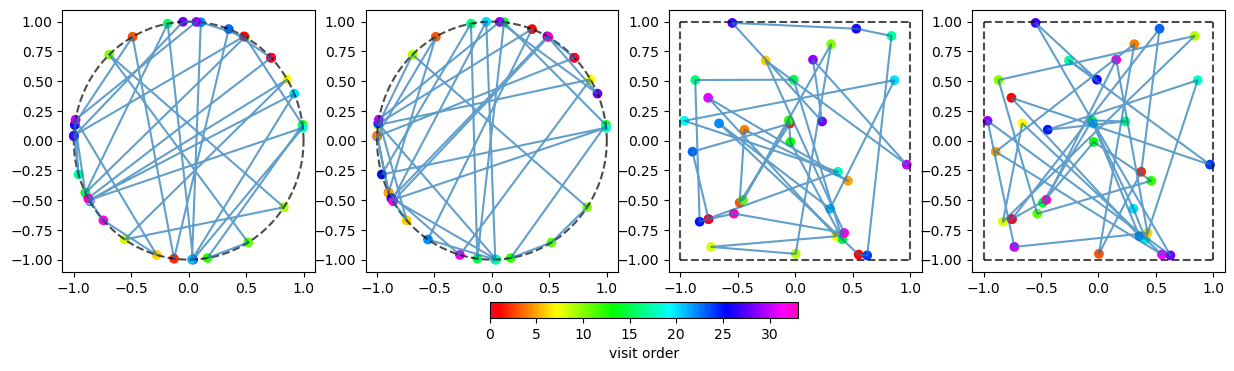

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df =pd.read_csv("./OUTPUT/positions.csv",sep="\t")
df1 =pd.read_csv("./OUTPUT/positions_square.csv",sep="\t")

def circle (theta) :
    return np.cos(theta),np.sin(theta)

def plot_square(ax):
    #ax[0].plot(x,y,linestyle='dashed',alpha= 0.7)
    ax.hlines(-1,-1,1,linestyle ='dashed',alpha= 0.7,color='black')
    ax.hlines(1,-1,1,linestyle ='dashed',alpha= 0.7,color='black')
    ax.vlines(-1,-1,1,linestyle ='dashed',alpha= 0.7,color='black')
    ax.vlines(1,-1,1,linestyle ='dashed',alpha= 0.7,color='black')
    
fig,ax = plt.subplots(1,4, figsize = (15,4))
theta = np.linspace(0,2*np.pi,100)
x,y = circle (theta)
colors = df[df['ch_index']==0]['index']

ax[0].plot(x,y,linestyle='dashed',alpha= 0.7,color='black')
ax[0].plot(df[df['ch_index']==0]['x'],df[df['ch_index']==0]['y'],alpha=0.7)
sc=ax[0].scatter(df[df['ch_index']==0]['x'],df[df['ch_index']==0]['y'],marker = 'o',c = colors, cmap = 'gist_rainbow')

ax[1].plot(x,y,linestyle='dashed',alpha= 0.7,color='black')
ax[1].plot(df[df['ch_index']==1]['x'],df[df['ch_index']==1]['y'],alpha=0.7)
ax[1].scatter(df[df['ch_index']==1]['x'],df[df['ch_index']==1]['y'],marker = 'o',c = colors,cmap = 'gist_rainbow')

plot_square(ax[2])
ax[2].plot(df1[df1['ch_index']==0]['x'],df1[df1['ch_index']==0]['y'],alpha=0.7)
ax[2].scatter(df1[df1['ch_index']==0]['x'],df1[df1['ch_index']==0]['y'],marker = 'o',c = colors,cmap = 'gist_rainbow')

plot_square(ax[3])
ax[3].plot(df1[df1['ch_index']==1]['x'],df1[df1['ch_index']==1]['y'],alpha=0.7)
ax[3].scatter(df1[df1['ch_index']==1]['x'],df1[df1['ch_index']==1]['y'],marker = 'o',c = colors,linestyle ='solid',cmap = 'gist_rainbow')

cbar = fig.colorbar(sc, ax=ax, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label("visit order")




plt.show()


#### selection

Once the configuration of the system has been built, the next step is building the **selection operator**. This is a function in geneticoptimizer that selects one of the elements  from the population with higher probability for the lower cost paths, meaning that the chromosomes in which the travelled distance is higher are less likely to be selected. I implemented this in two steps: first I sort the population from lower to higher cost. Cost is given from the L1 function, which is the sum of the distances between cities visited in order

```c++

void GeneticOptimizer::sort_population(){
	
	for (chromosome &x : _population) x.compute_cost();
	stable_sort (_population.begin(),_population.end(), []( chromosome a, chromosome b) {
              return a.get_cost() <b.get_cost();
          });

	   for (int i = 0; i < _population_size; i++) {
        _cost_values[i]=_population[i].get_cost();
    }
}

Then I randomly select a candidate from the ordered population, and accept it with a probability that decreases exponentially with the index of the element:

``` c++
int GeneticOptimizer::selection(Random &rnd){
	bool accept = false;
	int result =0;
	while(accept==false){
	
	int cand = int(rnd.Rannyu(0,_population_size));
	
	double r = rnd.Exp(3.);

	if (r>=cand/double(_population_size)) {
		result = cand;
		accept = true;
	}
	}
	return result;
}

I ran the selection for 5000 tries on a population of 100 chromosomes with 34 genes to get an histogram that represents the selection probabilty. The exponent 3 was chosen by trial and error, since I saw that with lower exponents the probabilty didn't favor the best candidates enough and the optimization wasn't converging.

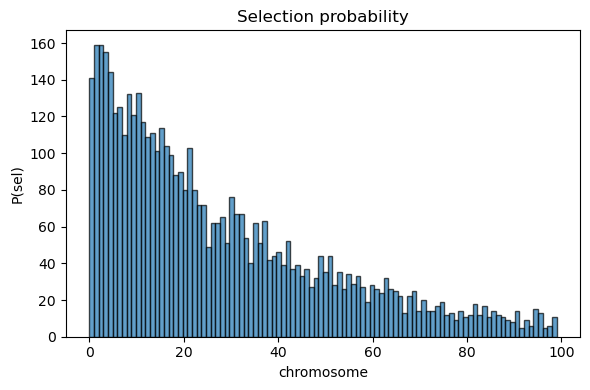

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('./OUTPUT/selection.csv',sep = '\t')

#CAPIRE SITUA BIN
fig = plt.subplots(figsize=(6,4))
plt.hist(df['selected'],bins =100,edgecolor = 'black',alpha =0.7)
plt.xlabel('chromosome')
plt.ylabel('P(sel)')
plt.title('Selection probability')
plt.tight_layout()
plt.show()

#### Crossover
Once the two parents are selected with the probability I explained, they can create offspring by crossover. This is a function that, after setting a cut point that is the same for both parents, shuffles the cities after the cut so that they appear in the order they are in th eother parent. I implemented this as function in the chromosome class, that takes as input the other parent:
``` c++
void chromosome:: crossover(int cut_pos,chromosome parent2){
	
	vector <gene> parent1_block (_chromosome.begin()+cut_pos,_chromosome.end()-1);

	vector <gene> ordered_block;
		for (gene x:parent2.get_genevector()){
		for (gene y : parent1_block){
			if (x.get_index()==y.get_index()) ordered_block.push_back(y);
		}
	}
	
	ordered_block.push_back(_chromosome[_ngenes]);
	
    _chromosome.erase(_chromosome.begin()+cut_pos,_chromosome.end());
    _chromosome.insert(_chromosome.end(),ordered_block.begin(),ordered_block.end());
		
}


In the optimization, the crossover is called with a probability of 80%, and if it is, the old chromosomes are inserted in the new population. 

#### mutations
To introduce some randomization in the process, I built some mutation functions in the chromosome class, each of which is called with a probability of 10% in a mutation function: 
``` c++
void chromosome::mutation(Random &rnd){
	double p_perm = 0.1;
	double p_shift=0.1;
	double p_inv = 0.1;
	double p_blockperm =0.1;
	
	double rand_perm = rnd.Rannyu();
	if (rand_perm<p_perm) permutation(rnd); // permutation of two genes in the chromosome
	
	double rand_shift=rnd.Rannyu();
	if(rand_shift<p_shift) shift_cities(rnd); //rigid shift of a block of genes to another position in the chromosome

	double rand_inv=rnd.Rannyu();
	if (rand_inv<p_inv) inversion(rnd); //chosen a block of genes in the chromosome, their order is inverted

	double rand_bl = rnd.Rannyu();
	if(rand_bl<p_blockperm) block_permutation(rnd); // permutation of two blocks of genes of the same length


**???? RANDOM SEARCH???**

population of 100 elements, 5000 generations. Mutation probabilities: 
- permutation 40%
- shift 30%
- inversion 20%
- block permutation 10%

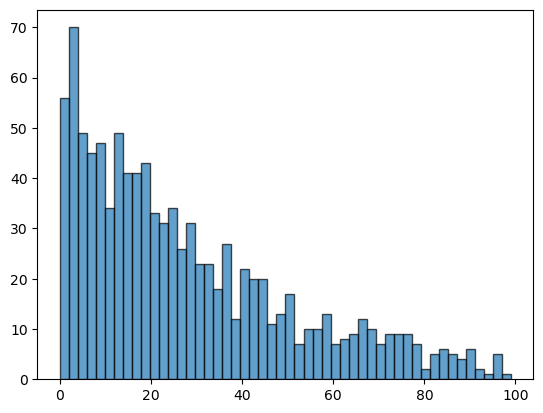

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('./OUTPUT/random_search.csv',sep='\t')

df.head()
plt.hist (df['results'], bins = 50,edgecolor='black',alpha=0.7)
plt.show()

#### Optimization
To summarize the actual optimization process:
- select two parents from given probability function
- crossover with probability 80%
- mutations with probability 10% each
- repeat until the new population is the same size as the old one, and the substitute the population
- repeat for N generations
- at the end sort the population and return the first element, which has the lower cost
``` c++
chromosome GeneticOptimizer::optimize (Random &rnd, int ngen){
	ofstream out("./OUTPUT/best_distance_square.csv");
	out<<"gen\tdist"<<endl;
	
	for (int i=0;i<ngen;i++){

		vector <chromosome> new_population;
	
		while(new_population.size()<=_population_size) {
		int p1 = selection(rnd);
		int p2=selection(rnd);

		chromosome parent1 = _population[p1];

		chromosome parent2 = _population[p2];

		double r =rnd.Rannyu();
		if(r<0.7){

		int cut_pos =int(rnd.Rannyu(1,_Ngenes));

		parent1.crossover(cut_pos,_population[p2]);
		parent2.crossover(cut_pos,_population[p1]);

	
		}
		
		parent1.mutation(rnd);
		parent2.mutation(rnd);
		new_population.push_back(parent1);
		new_population.push_back(parent2);
	}
	_population=new_population;
				sort_population();
	
		check_order();
		out<<i<<"\t"<<_population[0].get_cost()<<endl;

}
out.close();
sort_population();
check_order();
return _population[0];

}

In the following plots I show the results of the simulation of a population of 300 chromosomes for 300 generations. From the diagrams of the best path and the progressive value of the cost of the best chromosome in the population we can see that the algorithm converges to the right path after settling on a constant value for a while (WHY?)

**ADD AVERAGES**

minimum distance: 6.24306


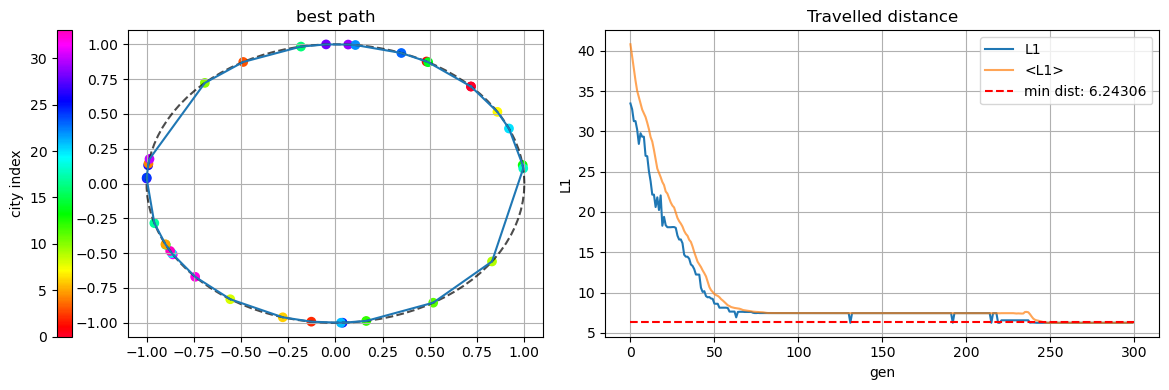

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df =pd.read_csv("./OUTPUT/best_path_circle.csv",sep="\t")

def circle (theta) :
    return np.cos(theta),np.sin(theta)

fig,ax = plt.subplots(1,2,figsize = (12,4))
theta = np.linspace(0,2*np.pi,100)
x,y = circle (theta)
colors = df['index']
ax[0].plot(x,y,linestyle='dashed',alpha= 0.7,color='black')
ax[0].plot(df['x'],df['y'])
sc=ax[0].scatter(df['x'],df['y'],marker = 'o',c=colors,cmap = 'gist_rainbow')
ax[0].set_title("best path")
ax[0].grid()



df1 = pd.read_csv('./OUTPUT/best_distance_circle.csv',sep ='\t')
df2= pd.read_csv('./OUTPUT/ave_distance_circle.csv',sep ='\t')
ax[1]. plot(df1['gen'],df1['dist'],label = 'L1')
ax[1]. plot(df2['gen'],df2['ave_dist'],alpha = 0.7,label = '<L1>')
ax[1].hlines(2*np.pi,0,300,color='r',linestyle = 'dashed',label = f'min dist: {np.min(df1['dist'])}')
ax[1].set_title("Travelled distance")
ax[1].set_ylabel("L1")
ax[1].set_xlabel("gen")
ax[1].legend()
plt.grid()
cbar = fig.colorbar(sc, ax=ax[0],location = 'left')
cbar.set_label("city index")
plt.tight_layout()
print(f'minimum distance: {np.min(df1['dist'])}')
plt.show()

minimum distance: 10.379


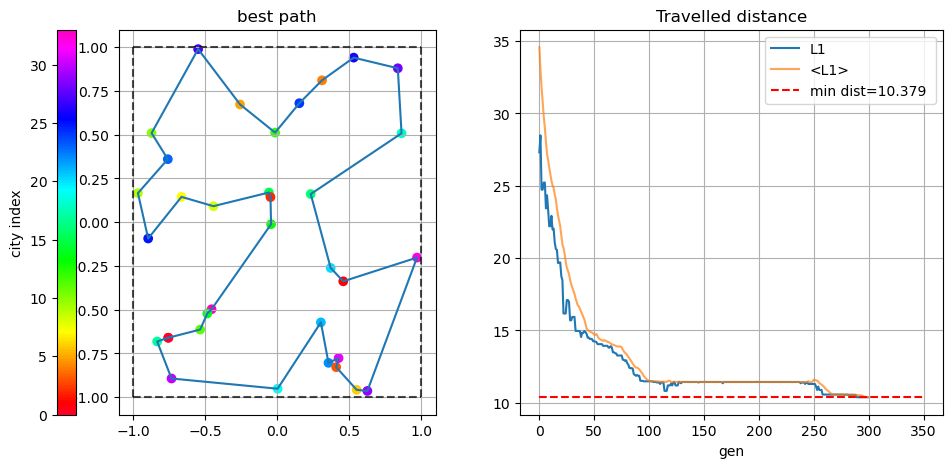

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df =pd.read_csv("./OUTPUT/best_path_square.csv",sep="\t")


fig,ax = plt.subplots(1,2,figsize = (12,5))
theta = np.linspace(0,2*np.pi,100)

colors = df['index']
#ax[0].plot(x,y,linestyle='dashed',alpha= 0.7)
ax[0].hlines(-1,-1,1,linestyle ='dashed',alpha= 0.7,color='black')
ax[0].hlines(1,-1,1,linestyle ='dashed',alpha= 0.7,color='black')
ax[0].vlines(-1,-1,1,linestyle ='dashed',alpha= 0.7,color='black')
ax[0].vlines(1,-1,1,linestyle ='dashed',alpha= 0.7,color='black')
ax[0].plot(df['x'],df['y'])
sc = ax[0].scatter(df['x'],df['y'],marker = 'o',c=colors,cmap = 'gist_rainbow')
ax[0].grid()
ax[0].set_title ('best path')


df1 = pd.read_csv('./OUTPUT/best_distance_square.csv',sep ='\t')
df2 = pd.read_csv('./OUTPUT/ave_distance_square.csv',sep ='\t')
ax[1]. plot(df1['gen'],df1['dist'],label = 'L1')
ax[1]. plot(df2['gen'],df2['ave_dist'],alpha =0.7,label ='<L1>')
ax[1].hlines(np.min(df1['dist']),0,350,color='r',linestyle = 'dashed',label = f'min dist={np.min(df1['dist'])} ')
ax[1].set_title('Travelled distance')
ax[1].set_xlabel('gen')
ax[1].legend()
print(f'minimum distance: {np.min(df1['dist'])}')
cbar = fig.colorbar(sc, ax=ax[0],location = 'left')
cbar.set_label("city index")
plt.grid()
plt.show()